# Galaxy10 DECaLS training with PyTorch

This notebook compares a deliberately small set of CNN configurations on the validation split. The test split is evaluated exactly once after selection. No metric in this unexecuted notebook is a portfolio result.

In [1]:
from copy import deepcopy
import gc
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix
from torch import nn

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from galaxy_classification.galaxy10 import (
    GALAXY10_CLASS_NAMES, GALAXY10_FILENAME, GALAXY10_SHAPE,
    Galaxy10CNN, Galaxy10TrainingConfig, class_weights, make_loaders,
    run_epoch, seed_everything, validate_manifest,
)

ARRAY_PATH = ROOT / 'data' / 'processed' / 'galaxy10-images.npy'
MANIFEST_PATH = ROOT / 'data' / 'image-manifests' / 'galaxy10-decals.csv'
manifest = pd.read_csv(MANIFEST_PATH)
validate_manifest(manifest, GALAXY10_SHAPE[0])
if not torch.cuda.is_available():
    raise RuntimeError(
        'CUDA is unavailable. Install requirements-gpu.txt and restart the kernel.'
    )
DEVICE = torch.device('cuda')
print('PyTorch:', torch.__version__)
print('CUDA runtime:', torch.version.cuda)
print('GPU:', torch.cuda.get_device_name(0))
print('Compute capability:', torch.cuda.get_device_capability(0))
DEVICE

PyTorch: 2.9.0+cu128
CUDA runtime: 12.8
GPU: NVIDIA GeForce RTX 5080 Laptop GPU
Compute capability: (12, 0)


device(type='cuda')

## Bounded training-only search

Learning rate, dropout, batch size, and weight decay vary across 24 bounded candidates. The CNN uses three RGB input channels and base_channels=48, producing feature widths 48 -> 96 -> 192 -> 384. The same morphology-preserving augmentation is applied to every training candidate. Class weights are calculated from the training split. Selection uses validation macro-F1 with six-epoch early stopping; the test loader is not touched here.

In [2]:
CANDIDATES = [
    Galaxy10TrainingConfig(
        learning_rate=learning_rate, base_channels=48, dropout=dropout,
        batch_size=batch_size, weight_decay=weight_decay, epochs=10
    )
    for learning_rate in (1e-3, 3e-4)
    for dropout in (0.3, 0.5, 0.7)
    for batch_size in (64, 128)
    for weight_decay in (0.0, 1e-4)
]
EARLY_STOPPING_PATIENCE = 6
# One worker overlaps loading with GPU work without overcommitting this Windows notebook.
NUMBER_OF_WORKERS = 1
weights = class_weights(manifest).to(DEVICE)
loss_function = nn.CrossEntropyLoss(weight=weights)

In [3]:
def fit_candidate(config, candidate_number, total_candidates):
    print(f'\nCandidate {candidate_number}/{total_candidates}: learning_rate={config.learning_rate:g}, dropout={config.dropout:.1f}, batch_size={config.batch_size}, weight_decay={config.weight_decay:g}', flush=True)
    seed_everything(config.random_state)
    loaders = make_loaders(
        ARRAY_PATH, manifest, config, number_of_workers=NUMBER_OF_WORKERS
    )
    model = Galaxy10CNN(config.base_channels, config.dropout).to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay
    )
    best_state = None
    best_macro_f1 = -1.0
    stale_epochs = 0
    history = []
    for epoch in range(config.epochs):
        train_metrics = run_epoch(
            model, loaders['train'], loss_function, DEVICE, optimizer
        )
        validation_metrics = run_epoch(
            model, loaders['validation'], loss_function, DEVICE
        )
        history.append({
            'epoch': epoch + 1,
            **{f'train_{key}': value for key, value in train_metrics.items()},
            **{f'validation_{key}': value for key, value in validation_metrics.items()},
        })
        if validation_metrics['macro_f1'] > best_macro_f1:
            best_macro_f1 = validation_metrics['macro_f1']
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            stale_epochs = 0
        else:
            stale_epochs += 1
        print(f'  epoch {epoch + 1:02d}/{config.epochs} | train_loss={train_metrics["loss"]:.4f} train_acc={train_metrics["accuracy"]:.4f} | val_loss={validation_metrics["loss"]:.4f} val_acc={validation_metrics["accuracy"]:.4f} val_balanced_acc={validation_metrics["balanced_accuracy"]:.4f} val_macro_f1={validation_metrics["macro_f1"]:.4f} best={best_macro_f1:.4f}', flush=True)
        if stale_epochs >= EARLY_STOPPING_PATIENCE:
            print('  early stopping: validation metric did not improve', flush=True)
            break
    del model, loaders
    gc.collect()
    torch.cuda.empty_cache()
    print(f'  candidate complete: best validation macro-F1={best_macro_f1:.4f}', flush=True)
    return best_state, pd.DataFrame(history), best_macro_f1

In [4]:
candidate_results = []
for candidate_number, config in enumerate(CANDIDATES, start=1):
    state, history, best_macro_f1 = fit_candidate(config, candidate_number, len(CANDIDATES))
    candidate_results.append({
        'config': config, 'state': state,
        'history': history, 'validation_macro_f1': best_macro_f1,
    })
print('\nGrid search complete. Validation ranking:', flush=True)
selection_table = pd.DataFrame([
    {
        'learning_rate': result['config'].learning_rate,
        'base_channels': result['config'].base_channels,
        'dropout': result['config'].dropout,
        'batch_size': result['config'].batch_size,
        'weight_decay': result['config'].weight_decay,
        'validation_macro_f1': result['validation_macro_f1'],
    }
    for result in candidate_results
]).sort_values('validation_macro_f1', ascending=False)
selection_table


Candidate 1/24: learning_rate=0.001, dropout=0.3, batch_size=64, weight_decay=0
  epoch 01/10 | train_loss=2.0528 train_acc=0.2303 | val_loss=1.9871 val_acc=0.2365 val_balanced_acc=0.2099 val_macro_f1=0.1470 best=0.1470
  epoch 02/10 | train_loss=1.8883 train_acc=0.2925 | val_loss=2.9750 val_acc=0.1650 val_balanced_acc=0.1748 val_macro_f1=0.0635 best=0.1470
  epoch 03/10 | train_loss=1.7941 train_acc=0.3406 | val_loss=1.8697 val_acc=0.3195 val_balanced_acc=0.3101 val_macro_f1=0.2586 best=0.2586
  epoch 04/10 | train_loss=1.7415 train_acc=0.3461 | val_loss=1.8661 val_acc=0.3162 val_balanced_acc=0.3296 val_macro_f1=0.2803 best=0.2803
  epoch 05/10 | train_loss=1.7042 train_acc=0.3707 | val_loss=1.6602 val_acc=0.4252 val_balanced_acc=0.4126 val_macro_f1=0.3903 best=0.3903
  epoch 06/10 | train_loss=1.6604 train_acc=0.3857 | val_loss=2.3728 val_acc=0.2511 val_balanced_acc=0.2241 val_macro_f1=0.1758 best=0.3903
  epoch 07/10 | train_loss=1.6204 train_acc=0.3980 | val_loss=1.5062 val_acc=0.

,learning_rate,base_channels,dropout,batch_size,weight_decay,validation_macro_f1
12,0.0003,48,0.3,64,0.0000,0.413664
2,0.0010,48,0.3,128,0.0000,0.412118
13,0.0003,48,0.3,64,0.0001,0.405590
1,0.0010,48,0.3,64,0.0001,0.402176
14,0.0003,48,0.3,128,0.0000,0.394178
16,0.0003,48,0.5,64,0.0000,0.392957
6,0.0010,48,0.5,128,0.0000,0.392489
0,0.0010,48,0.3,64,0.0000,0.390281
17,0.0003,48,0.5,64,0.0001,0.387395
18,0.0003,48,0.5,128,0.0000,0.383375


## Retrain the selected configuration

The grid search selected the configuration using validation macro-F1. The cell below can either use that configuration or use manually entered final hyperparameters. In both cases, training runs for up to 80 epochs, selects checkpoints with validation accuracy, and allows 25 stale epochs before stopping. The test split remains untouched.

In [5]:
selected = max(candidate_results, key=lambda item: item['validation_macro_f1'])
USE_GRID_BEST_CONFIG = True
MANUAL_FINAL_CONFIG = Galaxy10TrainingConfig(
    learning_rate=3e-4,
    base_channels=48,
    dropout=0.3,
    weight_decay=0.0,
    batch_size=64,
    epochs=80,
    random_state=42,
)
MANUAL_FINAL_EARLY_STOPPING_PATIENCE = 25
if USE_GRID_BEST_CONFIG:
    grid_config = selected['config']
    final_config = Galaxy10TrainingConfig(
        learning_rate=grid_config.learning_rate,
        base_channels=grid_config.base_channels,
        dropout=grid_config.dropout,
        weight_decay=grid_config.weight_decay,
        batch_size=grid_config.batch_size,
        epochs=80,
        random_state=grid_config.random_state,
    )
    FINAL_EARLY_STOPPING_PATIENCE = 25
else:
    final_config = MANUAL_FINAL_CONFIG
    FINAL_EARLY_STOPPING_PATIENCE = MANUAL_FINAL_EARLY_STOPPING_PATIENCE
seed_everything(final_config.random_state)
final_loaders = make_loaders(
    ARRAY_PATH, manifest, final_config, number_of_workers=NUMBER_OF_WORKERS
)
final_model = Galaxy10CNN(final_config.base_channels, final_config.dropout).to(DEVICE)
final_optimizer = torch.optim.Adam(
    final_model.parameters(), lr=final_config.learning_rate,
    weight_decay=final_config.weight_decay,
)
best_final_state = None
best_final_accuracy = -1.0
stale_epochs = 0
final_history = []
print(f'\nFinal training: up to {final_config.epochs} epochs, patience={FINAL_EARLY_STOPPING_PATIENCE}, selection=validation_accuracy', flush=True)
for epoch in range(final_config.epochs):
    train_metrics = run_epoch(final_model, final_loaders['train'], loss_function, DEVICE, final_optimizer)
    validation_metrics = run_epoch(final_model, final_loaders['validation'], loss_function, DEVICE)
    final_history.append({'epoch': epoch + 1, **{f'train_{key}': value for key, value in train_metrics.items()}, **{f'validation_{key}': value for key, value in validation_metrics.items()}})
    if validation_metrics['accuracy'] > best_final_accuracy:
        best_final_accuracy = validation_metrics['accuracy']
        best_final_state = {key: value.detach().cpu().clone() for key, value in final_model.state_dict().items()}
        stale_epochs = 0
    else:
        stale_epochs += 1
    print(f'  epoch {epoch + 1:02d}/{final_config.epochs} | train_loss={train_metrics["loss"]:.4f} train_acc={train_metrics["accuracy"]:.4f} | val_loss={validation_metrics["loss"]:.4f} val_acc={validation_metrics["accuracy"]:.4f} val_macro_f1={validation_metrics["macro_f1"]:.4f} best_val_acc={best_final_accuracy:.4f}', flush=True)
    if stale_epochs >= FINAL_EARLY_STOPPING_PATIENCE:
        print('  early stopping: validation accuracy did not improve', flush=True)
        break
final_model.load_state_dict(best_final_state)
final_history = pd.DataFrame(final_history)
print(f'Final training complete: best validation accuracy={best_final_accuracy:.4f}', flush=True)
final_history.tail()


Final training: up to 80 epochs, patience=25, selection=validation_accuracy
  epoch 01/80 | train_loss=2.0870 train_acc=0.2317 | val_loss=2.0639 val_acc=0.2180 val_macro_f1=0.1153 best_val_acc=0.2180
  epoch 02/80 | train_loss=1.9155 train_acc=0.2921 | val_loss=2.1106 val_acc=0.2481 val_macro_f1=0.2034 best_val_acc=0.2481
  epoch 03/80 | train_loss=1.8117 train_acc=0.3349 | val_loss=1.6884 val_acc=0.3823 val_macro_f1=0.3445 best_val_acc=0.3823
  epoch 04/80 | train_loss=1.7408 train_acc=0.3546 | val_loss=2.1879 val_acc=0.2425 val_macro_f1=0.1568 best_val_acc=0.3823
  epoch 05/80 | train_loss=1.6984 train_acc=0.3750 | val_loss=1.6211 val_acc=0.4090 val_macro_f1=0.3820 best_val_acc=0.4090
  epoch 06/80 | train_loss=1.6436 train_acc=0.3947 | val_loss=1.8459 val_acc=0.3387 val_macro_f1=0.2802 best_val_acc=0.4090
  epoch 07/80 | train_loss=1.6069 train_acc=0.4044 | val_loss=1.5478 val_acc=0.4361 val_macro_f1=0.4137 best_val_acc=0.4361
  epoch 08/80 | train_loss=1.5688 train_acc=0.4262 | va

,epoch,train_loss,train_accuracy,train_balanced_accuracy,train_macro_f1,validation_loss,validation_accuracy,validation_balanced_accuracy,validation_macro_f1
75,76,0.723788,0.747644,0.754944,0.732412,0.821296,0.703759,0.711195,0.672614
76,77,0.727289,0.741361,0.749768,0.723647,0.829488,0.710526,0.674856,0.685941
77,78,0.726273,0.746516,0.753795,0.729205,0.743204,0.745865,0.749458,0.719240
78,79,0.706644,0.746677,0.755211,0.730715,0.799259,0.725564,0.730951,0.689840
79,80,0.696841,0.753766,0.761498,0.737448,0.768914,0.736466,0.729473,0.703985


,precision,recall,f1-score,support
Disturbed Galaxies,0.440000,0.339506,0.383275,162.000000
Merging Galaxies,0.741379,0.618705,0.674510,278.000000
Round Smooth Galaxies,0.834158,0.848866,0.841448,397.000000
In-between Round Smooth Galaxies,0.921659,0.657895,0.767754,304.000000
Cigar Shaped Smooth Galaxies,0.555556,0.800000,0.655738,50.000000
Barred Spiral Galaxies,0.702703,0.846906,0.768095,307.000000
Unbarred Tight Spiral Galaxies,0.601719,0.763636,0.673077,275.000000
Unbarred Loose Spiral Galaxies,0.593085,0.565990,0.579221,394.000000
Edge-on Galaxies without Bulge,0.865385,0.845070,0.855107,213.000000
Edge-on Galaxies with Bulge,0.801948,0.879004,0.838710,281.000000


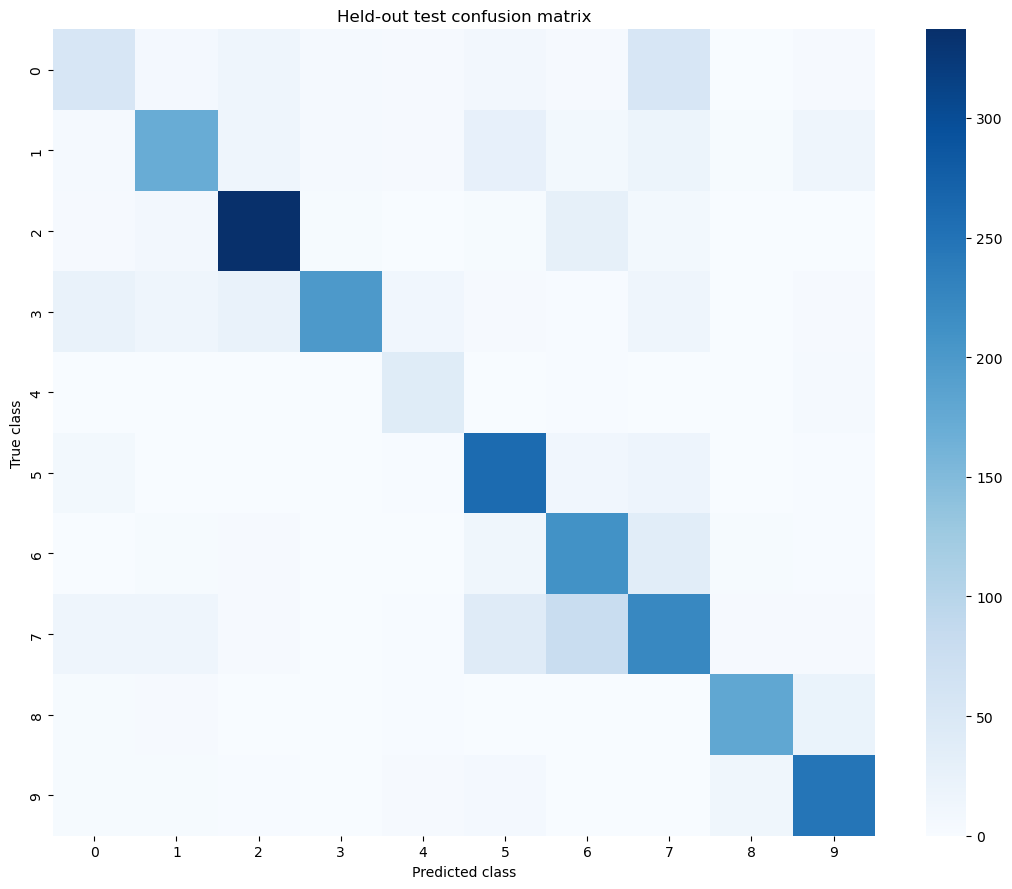

In [ ]:
truth, predictions = [], []
final_model.eval()
with torch.no_grad():
    for inputs, targets in final_loaders['test']:
        logits = final_model(inputs.to(DEVICE, non_blocking=True))
        truth.extend(targets.tolist())
        predictions.extend(logits.argmax(dim=1).cpu().tolist())
report = pd.DataFrame(classification_report(
    truth, predictions, target_names=GALAXY10_CLASS_NAMES,
    output_dict=True, zero_division=0
)).transpose()
display(report)
matrix = confusion_matrix(truth, predictions)
figure, axis = plt.subplots(figsize=(11, 9))
sns.heatmap(matrix, cmap='Blues', ax=axis)
axis.set(xlabel='Predicted class', ylabel='True class', title='Held-out test confusion matrix')
figure.tight_layout()